In [1]:
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal


def encontrar_raiz_repo(marcadores=(".git", "data")):
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        if all((pasta / m).exists() for m in marcadores):
            return pasta
    raise FileNotFoundError(f"Nao achei {marcadores} subindo a partir de {Path.cwd()}")


RAIZ = encontrar_raiz_repo()
pd.set_option("display.width", 200)

## Importando

In [3]:
clusters = pd.read_csv(RAIZ / "data/processed/clusters_risco.csv", index_col=0)
metadata = pd.read_csv(RAIZ / "data/raw/metadata_recorte.csv", index_col=0)
df = clusters.join(metadata.drop(columns=["Species"]), how="left")

print(df.shape)
df.head()

(2226, 12)


,cluster,conjunto,perfil,Species,Source,Date,Location,BioSample,Estado,Região,source_type,WHO_Priority
sample,,,,,,,,,,,,
GCA_029076165.1,2,treino,C2: carbapenemase serina (plasm. 61%),Klebsiella pneumoniae,urine,2021.0,Brazil,SAMN33566985,NaN,NaN,Urinary,Critical
GCF_001420335.1,2,treino,C2: carbapenemase serina (plasm. 61%),Acinetobacter baumannii,rectal swab,2012.0,"Hospital das Clinicas, Sao Paulo",SAMN04196794,SP,Sul,Gastrointestinal,Critical
GCA_002304205.1,1,treino,C1: ESBL sem carbapenemase,Klebsiella pneumoniae,rectal swab,2011.0,Brazil,SAMN07595147,NaN,NaN,Gastrointestinal,Critical
GCA_031011085.1,3,treino,C3: carbapenemase serina + ESBL (plasm. 96%),Klebsiella pneumoniae,Surveillance Swab,2019.0,Brazil,SAMN36785147,NaN,NaN,Other,Critical
GCA_031630615.1,0,treino,C0: MBL + ESBL (plasm. 80%),Enterobacter hormaechei,blood,2020.0,Sao Paulo,SAMN30951027,SP,Sul,Blood,Critical


In [4]:
print(df.groupby("cluster")["perfil"].first().to_string())

cluster
0                          C0: MBL + ESBL (plasm. 80%)
1                           C1: ESBL sem carbapenemase
2                C2: carbapenemase serina (plasm. 61%)
3         C3: carbapenemase serina + ESBL (plasm. 96%)
4    C4: carbapenemase serina + metilase 16S (plasm...
5                C5: sem mecanismo principal adquirido


In [5]:
# rótulo curto pro eixo dos heatmaps
ROTULO = {
    0: "C0 MBL+ESBL",
    1: "C1 ESBL",
    2: "C2 carb.",
    3: "C3 carb. +ESBL",
    4: "C4 carb. +metilase 16S",
    5: "C5 sem mecanismo",
}

df["cl"] = pd.Categorical(df["cluster"].map(ROTULO), categories=list(ROTULO.values()), ordered=True)
print(f"\n{len(df)} genomas")
df["cl"].value_counts().sort_index()


2226 genomas


C0 MBL+ESBL               219
C1 ESBL                   315
C2 carb.                  491
C3 carb. +ESBL            438
C4 carb. +metilase 16S    297
C5 sem mecanismo          466
Name: cl, dtype: int64

In [16]:
df_train = pd.read_csv("data/processed/df_estruturada/df_train_risco.csv", index_col=0).join(df[["cluster"]])
df_valid  = pd.read_csv("data/processed/df_estruturada/df_valid_risco.csv",  index_col=0).join(df[["cluster"]])
df_test  = pd.read_csv("data/processed/df_estruturada/df_test_risco.csv",  index_col=0).join(df[["cluster"]])

## Classificação

In [19]:
from notebooks.src.classifier import Classifier

In [17]:
print(df_train.shape)
df_train.head()

(1558, 17)


,has_carbapenemase,has_mbl,has_carbapenemase_serina,n_carbapenemases,has_esbl,has_ampc_adquirida,n_bl_adquiridas,has_16s_metilase,n_ame,has_mcr,has_pmqr,n_classes_adquiridas,n_genes_adquiridos,pct_adquiridos_plasmidial,carbapenemase_plasmidial,Species,cluster
sample,,,,,,,,,,,,,,,,,
GCA_029076165.1,1,0,1,1,0,0,2,0,3,0,0,6,10,0.700000,1,Klebsiella pneumoniae,2
GCF_001420335.1,1,0,1,1,0,0,2,0,3,0,0,3,6,0.666667,0,Acinetobacter baumannii,2
GCA_002304205.1,0,0,0,0,1,0,1,0,5,0,1,6,11,0.636364,0,Klebsiella pneumoniae,1
GCA_031011085.1,1,0,1,1,1,0,4,0,5,0,1,8,17,0.764706,1,Klebsiella pneumoniae,3
GCA_031630615.1,1,1,0,1,1,1,3,0,7,1,1,8,21,0.476190,0,Enterobacter hormaechei,0


In [23]:
clf = Classifier(df_train, 
                 target="cluster", 
                 df_test=df_valid, 
                 descartar=["Species"])
# clf.X -> todas as colunas de df_train exceto "cluster" e "Species"
# clf.y -> a coluna "cluster"

### RF

--- Treinando rf (1558 amostras, 15 features) ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'rf__criterion': 'gini', 'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 50, 'var_threshold__threshold': 0.0001}
Melhor balanced_accuracy (CV): 0.9961


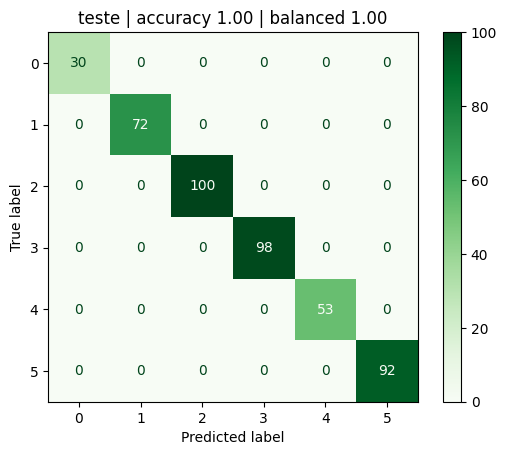


Classification Report (teste):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        72
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00        98
           4       1.00      1.00      1.00        53
           5       1.00      1.00      1.00        92

    accuracy                           1.00       445
   macro avg       1.00      1.00      1.00       445
weighted avg       1.00      1.00      1.00       445

Total de variáveis originais pré-processadas: 15
Total de variáveis após VarianceThreshold:    15
Total de variáveis selecionadas no modelo:    15

--- Lista das Variáveis Selecionadas ---
1. num__has_carbapenemase
2. num__has_mbl
3. num__has_carbapenemase_serina
4. num__n_carbapenemases
5. num__has_esbl
6. num__has_ampc_adquirida
7. num__n_bl_adquiridas
8. num__has_16s_metilase
9. num__n_ame
10. num__has_mcr
11. num__has

array([1, 5, 4, 1, 1, 2, 5, 3, 2, 3, 3, 3, 1, 3, 5, 1, 1, 3, 3, 3, 2, 4,
       4, 3, 5, 3, 1, 4, 5, 5, 5, 2, 3, 5, 2, 4, 4, 2, 5, 3, 2, 2, 4, 3,
       1, 2, 3, 3, 4, 3, 5, 1, 0, 0, 2, 2, 4, 0, 3, 1, 3, 2, 1, 5, 1, 3,
       5, 4, 1, 5, 3, 4, 0, 2, 4, 5, 2, 1, 5, 3, 5, 5, 1, 5, 2, 0, 3, 3,
       2, 3, 1, 5, 4, 5, 1, 5, 5, 0, 1, 1, 5, 3, 2, 4, 1, 5, 2, 1, 2, 3,
       2, 2, 3, 2, 2, 0, 2, 5, 1, 1, 0, 2, 3, 5, 2, 5, 3, 2, 2, 3, 2, 2,
       5, 3, 2, 3, 5, 5, 3, 3, 5, 3, 4, 2, 3, 2, 0, 5, 3, 5, 0, 5, 5, 5,
       2, 2, 1, 2, 5, 5, 1, 5, 3, 2, 2, 2, 5, 1, 2, 5, 4, 5, 0, 4, 5, 4,
       2, 2, 2, 5, 5, 4, 3, 5, 4, 1, 2, 3, 4, 1, 1, 5, 2, 4, 4, 5, 3, 1,
       3, 2, 0, 3, 3, 2, 3, 2, 4, 2, 5, 4, 2, 1, 3, 2, 1, 2, 1, 4, 5, 4,
       3, 2, 2, 4, 2, 4, 1, 3, 4, 2, 5, 0, 5, 1, 3, 5, 5, 3, 3, 2, 0, 0,
       1, 3, 1, 5, 4, 3, 5, 1, 1, 5, 1, 2, 4, 2, 3, 4, 1, 2, 3, 3, 5, 2,
       3, 4, 1, 1, 5, 0, 5, 3, 3, 3, 2, 1, 1, 3, 0, 2, 2, 2, 5, 5, 1, 5,
       5, 3, 4, 3, 1, 5, 1, 5, 1, 2, 4, 3, 5, 1, 3,

In [ ]:
# "knn", "svm", "rf", "gbm", "nb", "nn"
metricas, y_pred = clf.classify("rf")        

clf.modelos_["rf"].predict(df_valid)

### KNN

--- Treinando knn (1558 amostras, 15 features) ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform', 'var_threshold__threshold': 0.0001}
Melhor balanced_accuracy (CV): 0.9925


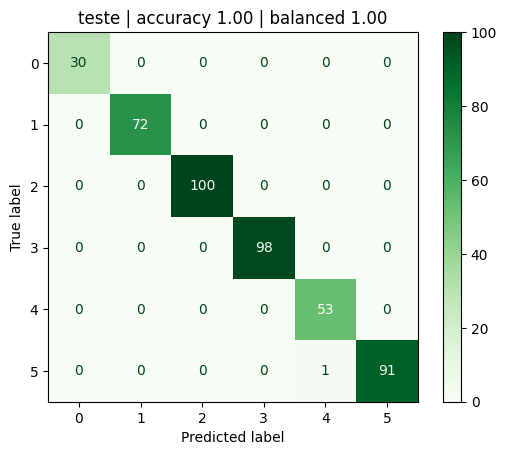


Classification Report (teste):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        72
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00        98
           4       0.98      1.00      0.99        53
           5       1.00      0.99      0.99        92

    accuracy                           1.00       445
   macro avg       1.00      1.00      1.00       445
weighted avg       1.00      1.00      1.00       445

Total de variáveis originais pré-processadas: 15
Total de variáveis após VarianceThreshold:    15
Total de variáveis selecionadas no modelo:    15

--- Lista das Variáveis Selecionadas ---
1. num__has_carbapenemase
2. num__has_mbl
3. num__has_carbapenemase_serina
4. num__n_carbapenemases
5. num__has_esbl
6. num__has_ampc_adquirida
7. num__n_bl_adquiridas
8. num__has_16s_metilase
9. num__n_ame
10. num__has_mcr
11. num__has

array([1, 5, 4, 1, 1, 2, 5, 3, 2, 3, 3, 3, 1, 3, 5, 1, 1, 3, 3, 3, 2, 4,
       4, 3, 5, 3, 1, 4, 5, 5, 5, 2, 3, 5, 2, 4, 4, 2, 5, 3, 2, 2, 4, 3,
       1, 2, 3, 3, 4, 3, 5, 1, 0, 0, 2, 2, 4, 0, 3, 1, 3, 2, 1, 5, 1, 3,
       5, 4, 1, 5, 3, 4, 0, 2, 4, 5, 2, 1, 5, 3, 5, 5, 1, 5, 2, 0, 3, 3,
       2, 3, 1, 5, 4, 5, 1, 5, 5, 0, 1, 1, 5, 3, 2, 4, 1, 5, 2, 1, 2, 3,
       2, 2, 3, 2, 2, 0, 2, 5, 1, 1, 0, 2, 3, 5, 2, 5, 3, 2, 2, 3, 2, 2,
       5, 3, 2, 3, 5, 5, 3, 3, 5, 3, 4, 2, 3, 2, 0, 5, 3, 5, 0, 5, 5, 5,
       2, 2, 1, 2, 5, 5, 1, 5, 3, 2, 2, 2, 5, 1, 2, 5, 4, 5, 0, 4, 5, 4,
       2, 2, 2, 5, 5, 4, 3, 5, 4, 1, 2, 3, 4, 1, 1, 5, 2, 4, 4, 5, 3, 1,
       3, 2, 0, 3, 3, 2, 3, 2, 4, 2, 5, 4, 2, 1, 3, 2, 1, 2, 1, 4, 4, 4,
       3, 2, 2, 4, 2, 4, 1, 3, 4, 2, 5, 0, 5, 1, 3, 5, 5, 3, 3, 2, 0, 0,
       1, 3, 1, 5, 4, 3, 5, 1, 1, 5, 1, 2, 4, 2, 3, 4, 1, 2, 3, 3, 5, 2,
       3, 4, 1, 1, 5, 0, 5, 3, 3, 3, 2, 1, 1, 3, 0, 2, 2, 2, 5, 5, 1, 5,
       5, 3, 4, 3, 1, 5, 1, 5, 1, 2, 4, 3, 5, 1, 3,

In [25]:
# "knn", "svm", "rf", "gbm", "nb", "nn"
metricas, y_pred = clf.classify("knn")        

clf.modelos_["knn"].predict(df_valid)

### SVM

--- Treinando svm (1558 amostras, 15 features) ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear', 'var_threshold__threshold': 0.0001}
Melhor balanced_accuracy (CV): 0.9977


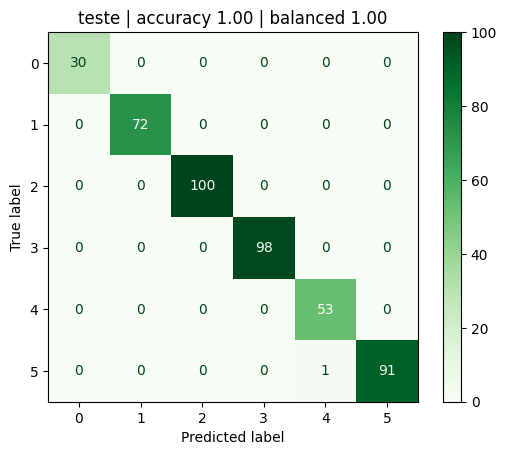


Classification Report (teste):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        72
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00        98
           4       0.98      1.00      0.99        53
           5       1.00      0.99      0.99        92

    accuracy                           1.00       445
   macro avg       1.00      1.00      1.00       445
weighted avg       1.00      1.00      1.00       445

Total de variáveis originais pré-processadas: 15
Total de variáveis após VarianceThreshold:    15
Total de variáveis selecionadas no modelo:    15

--- Lista das Variáveis Selecionadas ---
1. num__has_carbapenemase
2. num__has_mbl
3. num__has_carbapenemase_serina
4. num__n_carbapenemases
5. num__has_esbl
6. num__has_ampc_adquirida
7. num__n_bl_adquiridas
8. num__has_16s_metilase
9. num__n_ame
10. num__has_mcr
11. num__has

array([1, 5, 4, 1, 1, 2, 5, 3, 2, 3, 3, 3, 1, 3, 5, 1, 1, 3, 3, 3, 2, 4,
       4, 3, 5, 3, 1, 4, 5, 5, 5, 2, 3, 5, 2, 4, 4, 2, 5, 3, 2, 2, 4, 3,
       1, 2, 3, 3, 4, 3, 5, 1, 0, 0, 2, 2, 4, 0, 3, 1, 3, 2, 1, 5, 1, 3,
       5, 4, 1, 5, 3, 4, 0, 2, 4, 5, 2, 1, 5, 3, 5, 5, 1, 5, 2, 0, 3, 3,
       2, 3, 1, 5, 4, 5, 1, 5, 5, 0, 1, 1, 5, 3, 2, 4, 1, 5, 2, 1, 2, 3,
       2, 2, 3, 2, 2, 0, 2, 5, 1, 1, 0, 2, 3, 5, 2, 5, 3, 2, 2, 3, 2, 2,
       5, 3, 2, 3, 5, 5, 3, 3, 5, 3, 4, 2, 3, 2, 0, 5, 3, 5, 0, 5, 5, 5,
       2, 2, 1, 2, 5, 5, 1, 5, 3, 2, 2, 2, 5, 1, 2, 5, 4, 5, 0, 4, 5, 4,
       2, 2, 2, 5, 5, 4, 3, 5, 4, 1, 2, 3, 4, 1, 1, 5, 2, 4, 4, 5, 3, 1,
       3, 2, 0, 3, 3, 2, 3, 2, 4, 2, 5, 4, 2, 1, 3, 2, 1, 2, 1, 4, 4, 4,
       3, 2, 2, 4, 2, 4, 1, 3, 4, 2, 5, 0, 5, 1, 3, 5, 5, 3, 3, 2, 0, 0,
       1, 3, 1, 5, 4, 3, 5, 1, 1, 5, 1, 2, 4, 2, 3, 4, 1, 2, 3, 3, 5, 2,
       3, 4, 1, 1, 5, 0, 5, 3, 3, 3, 2, 1, 1, 3, 0, 2, 2, 2, 5, 5, 1, 5,
       5, 3, 4, 3, 1, 5, 1, 5, 1, 2, 4, 3, 5, 1, 3,

In [26]:
# "knn", "svm", "rf", "gbm", "nb", "nn"
metricas, y_pred = clf.classify("svm")        

clf.modelos_["svm"].predict(df_valid)